In [1]:
# Load packages
import dropbox
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.chdir("/users/eleves-a/2025/louise.gatty")
os.getcwd()

'/users/eleves-a/2025/louise.gatty'

# 1. Train-test split

In [2]:
# Load main data
df = pd.read_csv("https://www.dropbox.com/scl/fi/snny0t6c5h4zcy23nwtz9/AirQualityData_Imputed_Feature_Engineered.csv?rlkey=hj7nbjuve3cp8ecvxvwbfeh8m&st=vtqbw1l9&dl=1")
df.head()

,Date,ninsee,no2,o3,pm10,Smoothed_no2,Smoothed_no2_L2,Smoothed_no2_L3,Smoothed_o3,Smoothed_o3_L2,...,Eletricity_Total_2017,Electricity_Electricity_2017,GHG_Tertiary_2021,GHG_Agriculture_2021,GHG_Transport_Other_2021,GHG_Trash_2021,GHG_Energy_2021,GHG_Industry_2021,GHG_Residential_2021,GHG_Road_2021
0,2017-01-04,75101,34,13,34,26.350006,23.201945,20.000000,7.779456,7.328373,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
1,2017-01-05,75101,38,17,39,28.391244,26.350006,23.201945,11.285714,7.779456,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
2,2017-01-06,75101,35,13,44,30.955137,28.391244,26.350006,15.123582,11.285714,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
3,2017-01-07,75101,31,9,50,32.034423,30.955137,28.391244,13.697327,15.123582,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
4,2017-01-08,75101,36,7,47,31.758409,32.034423,30.955137,10.542476,13.697327,...,1.969938,2.210248,1.91574,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056


In [21]:
# Load train and test communes
test_communes = pd.read_csv("XCroissants-Predicting-Air-Quality/03. Prediction/00.A Train-Test-Communes/Test-Communes.csv")
train_communes = pd.read_csv("XCroissants-Predicting-Air-Quality/03. Prediction/00.A Train-Test-Communes/Train-Communes.csv")
train_communes.head()

,Commune
0,77415
1,77464
2,77168
3,77533
4,77185


In [22]:
# Merge main data with train and test communes
train_merged = pd.merge(df, train_communes, left_on="ninsee", right_on="Commune", how="right")
test_merged = pd.merge(df, test_communes, left_on="ninsee", right_on="Commune", how="right")
train_merged.head()

,Date,ninsee,no2,o3,pm10,Smoothed_no2,Smoothed_no2_L2,Smoothed_no2_L3,Smoothed_o3,Smoothed_o3_L2,...,Electricity_Electricity_2017,GHG_Tertiary_2021,GHG_Agriculture_2021,GHG_Transport_Other_2021,GHG_Trash_2021,GHG_Energy_2021,GHG_Industry_2021,GHG_Residential_2021,GHG_Road_2021,Commune
0,2017-01-04,77415,17,16,25,11.796488,9.766870,9.000000,9.758413,10.504198,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415
1,2017-01-05,77415,16,19,32,12.594571,11.796488,9.766870,12.853007,9.758413,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415
2,2017-01-06,77415,16,18,30,13.116876,12.594571,11.796488,15.900701,12.853007,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415
3,2017-01-07,77415,17,15,49,13.559072,13.116876,12.594571,16.941538,15.900701,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415
4,2017-01-08,77415,21,6,60,14.086821,13.559072,13.116876,15.978919,16.941538,...,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534,77415


In [23]:
# Create working train and test datasets
train_df = train_merged.drop(columns=["Commune"])
test_df = test_merged.drop(columns=["Commune"])

# Delete merged datasets to save memory
del train_merged
del test_merged

train_df.head()

,Date,ninsee,no2,o3,pm10,Smoothed_no2,Smoothed_no2_L2,Smoothed_no2_L3,Smoothed_o3,Smoothed_o3_L2,...,Eletricity_Total_2017,Electricity_Electricity_2017,GHG_Tertiary_2021,GHG_Agriculture_2021,GHG_Transport_Other_2021,GHG_Trash_2021,GHG_Energy_2021,GHG_Industry_2021,GHG_Residential_2021,GHG_Road_2021
0,2017-01-04,77415,17,16,25,11.796488,9.766870,9.000000,9.758413,10.504198,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534
1,2017-01-05,77415,16,19,32,12.594571,11.796488,9.766870,12.853007,9.758413,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534
2,2017-01-06,77415,16,18,30,13.116876,12.594571,11.796488,15.900701,12.853007,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534
3,2017-01-07,77415,17,15,49,13.559072,13.116876,12.594571,16.941538,15.900701,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534
4,2017-01-08,77415,21,6,60,14.086821,13.559072,13.116876,15.978919,16.941538,...,-0.27177,-0.366652,-0.061467,0.748248,0.774261,0.333015,-0.426473,-0.243274,-0.071385,1.21534


# 2. Baseline OLS

In [24]:
# Load machine learning packages
import sklearn as sk
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.impute import SimpleImputer

## 2.1. Data preprocessing

LinearRegression() does not work with NaN values. So we will create flags for them and impute the median for the computation. This will:
- do the computing on the median value (so that it does not stop),
- adjust the weight of the was_na columns (to understand that when the value was missing, the impact on air quality was maybe different).

In [25]:
# Drop date variable
train_df = train_df.drop(columns=['Date'])
test_df = test_df.drop(columns=['Date'])

# Flag NaN values
for col in train_df.columns:
    train_df[f'{col}_was_na'] = train_df[col].isna().astype(int)
for col in test_df.columns:
    test_df[f'{col}_was_na'] = test_df[col].isna().astype(int)

# Imputing missing values with median
imputer = SimpleImputer(strategy='median').set_output(transform="pandas")
train_df = imputer.fit_transform(train_df)
test_df = imputer.transform(test_df)

type(train_df)

/tmp/ipykernel_1186645/2706398004.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f'{col}_was_na'] = train_df[col].isna().astype(int)
/tmp/ipykernel_1186645/2706398004.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f'{col}_was_na'] = train_df[col].isna().astype(int)
/tmp/ipykernel_1186645/2706398004.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

pandas.core.frame.DataFrame

In [26]:
# Separate features and target variables (X for features, y for targets)
X_train = train_df.drop(columns=['no2', 'o3', 'pm10'])
y_train_no2 = train_df['no2']
y_train_o3 = train_df['o3']
y_train_pm10 = train_df['pm10']

# Prepare test data
X_test = test_df.drop(columns=['no2', 'o3', 'pm10'])
y_test_no2 = test_df['no2']
y_test_o3 = test_df['o3']
y_test_pm10 = test_df['pm10']

In [27]:
# OLS Regression for NO2
model_ols_no2 = LinearRegression()
model_ols_no2.fit(X_train, y_train_no2)

# OLS Regression for O3
model_ols_o3 = LinearRegression()
model_ols_o3.fit(X_train, y_train_o3)

# OLS Regression for PM10
model_ols_pm10 = LinearRegression()
model_ols_pm10.fit(X_train, y_train_pm10)

LinearRegression()

## 3.2. Predictions

In [28]:
# Predictions and evaluation for NO2
y_pred_no2 = model_ols_no2.predict(X_test)
rmse_no2 = root_mean_squared_error(y_test_no2, y_pred_no2)
r2_no2 = r2_score(y_test_no2, y_pred_no2)

# Predictions and evaluation for O3
y_pred_o3 = model_ols_o3.predict(X_test)
rmse_o3 = root_mean_squared_error(y_test_o3, y_pred_o3)
r2_o3 = r2_score(y_test_o3, y_pred_o3)

# Predictions and evaluation for PM10
y_pred_pm10 = model_ols_pm10.predict(X_test)
rmse_pm10 = root_mean_squared_error(y_test_pm10, y_pred_pm10)
r2_pm10 = r2_score(y_test_pm10, y_pred_pm10)

# Print results
print(f" NO2 – RMSE: {rmse_no2:.2f}, R²: {r2_no2:.2f}, Stdev no2: {y_train_no2.std():.2f}")
print(f" O3 – RMSE: {rmse_o3:.2f}, R²: {r2_o3:.2f}, Stdev o3: {y_train_o3.std():.2f}")
print(f" PM10 – RMSE: {rmse_pm10:.2f}, R²: {r2_pm10:.2f}, Stdev pm10: {y_train_pm10.std():.2f}")

 NO2 – RMSE: 5.24, R²: 0.67, Stdev no2: 9.34
 O3 – RMSE: 5.19, R²: 0.77, Stdev o3: 10.87
 PM10 – RMSE: 7.47, R²: 0.72, Stdev pm10: 14.21


## 3.3. Diagnosis

Results are acceptable for baseline OLS. The RMSE is a little too high considering the stdev of the target variable. Possible improvements are:
- dropping variables that are highly correlated, bc the variance of the estimators increase with the collinearity: $Var(\hat \beta​)=\sigma ^2(X^TX)^{-1}$ and the matrix is nearly singular,
- implementing more complex models.

In [ ]:
results_df = pd.read_csv("/Users/antonioraphael/Documents/PROJECT-CLONES/XCroissants-Predicting-Air-Quality/03. Prediction/Outputs-o3/predictions_vs_actuals.csv")
model = lgb.Booster(model_file="/Users/antonioraphael/Documents/PROJECT-CLONES/XCroissants-Predicting-Air-Quality/03. Prediction/Outputs-o3/lgbm_o3_model.txt")
feature_cols = json.load(open("/Users/antonioraphael/Documents/PROJECT-CLONES/XCroissants-Predicting-Air-Quality/03. Prediction/Outputs-o3/feature_cols.json"))
best_params  = json.load(open("/Users/antonioraphael/Documents/PROJECT-CLONES/XCroissants-Predicting-Air-Quality/03. Prediction/Outputs-o3/best_params.json"))

test = pd.read_csv("/Users/antonioraphael/Documents/PROJECT-CLONES/XCroissants-Predicting-Air-Quality/03. Prediction/00.A Train-Test-Communes/Test-Communes.csv")
data = pd.read_csv("/Users/antonioraphael/Documents/PROJECT-CLONES/Data-Storage/AirQualityData/PredictionData/AirQualityData_Imputed_Feature_Engineered.csv")

test_df = data[data['ninsee'].isin(test['Commune'])]
test_df_o3 = test_df.drop(columns = ['no2', 'pm10'])

In [ ]:
y_true_no2 = y_test_no2["no2"].values
#y_pred_no2 = model.predict(test_df_no2[feature_cols], num_iteration=model.best_iteration_)

# ninsee,actual_no2,predicted_no2,residual,abs_error
pd.DataFrame({
    "ninsee"         : test_df_no2["ninsee"].values,
    "actual_no2"    : y_true_no2,
    "predicted_no2" : y_pred_no2,
    "residual"       : y_true_no2 - y_pred_no2,
    "abs_error"      : np.abs(y_true_no2 - y_pred_no2),
}).to_csv(os.path.join(OUTPUT_DIR, "predictions_vs_actuals.csv"), index=False)

# 3. Elastic net

We choose an Elastic Net model as it combines the advantages of the LASSO and Ridge models:
- capable of deleting variables,
- reduce the importance of some variables without dropping them to zero.

It also converges (loss function is convex).

## 3.1. Preprocessing and pipeline

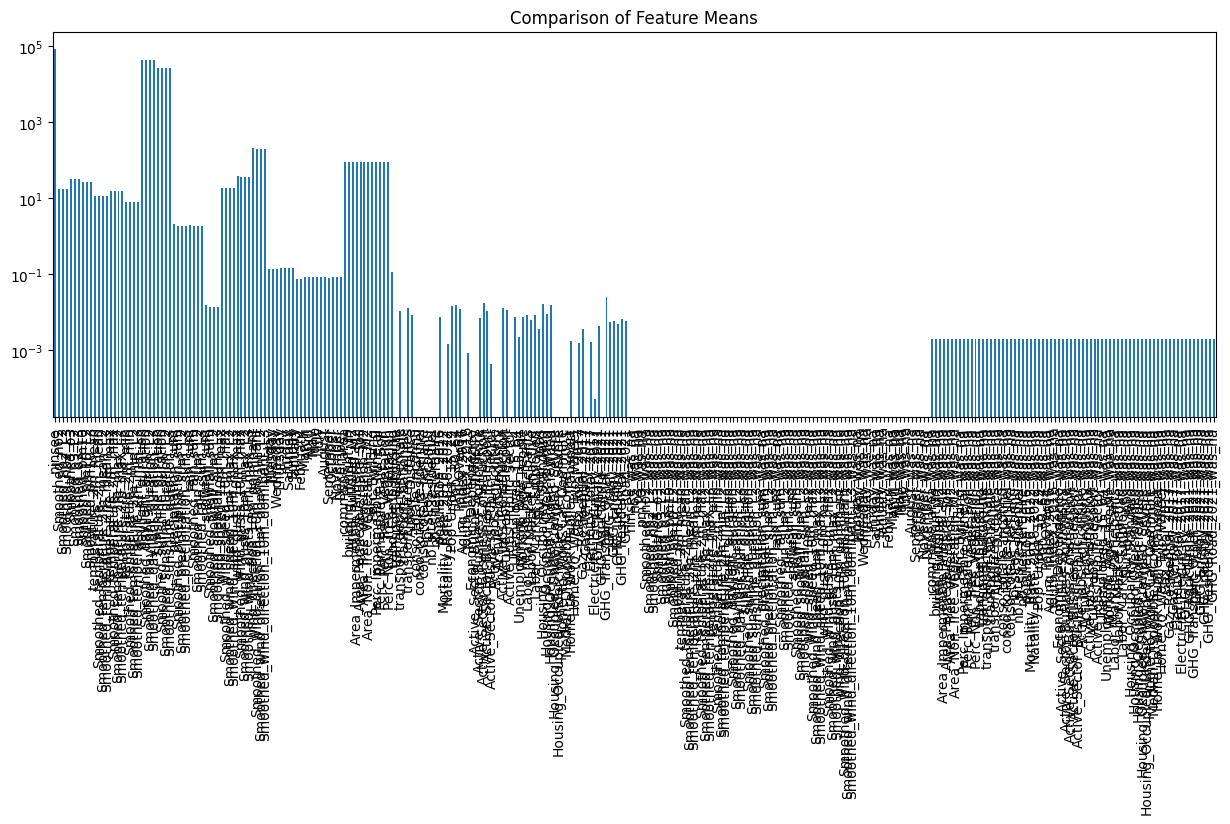

In [11]:
# Plotting the 'mean' of all features to see scale differences
X_train.describe().T['mean'].plot(kind='bar', figsize=(15, 5))
plt.title("Comparison of Feature Means")
plt.yscale('log')
plt.show()

In [12]:
# Load packages for Elastic Net and preprocessing
#pip install category_encoders
from sklearn.linear_model import ElasticNetCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

In [13]:
# Count the occurrences of each class in the target variable
counts_no2 = y_train_no2.value_counts()
counts_pm10 = y_train_pm10.value_counts()
counts_o3 = y_train_o3.value_counts()

# NO2: Group the classes with less than 11 samples into 'Other' category
rare_classes_no2 = counts_no2[counts_no2 < 11].index
y_train_no2 = y_train_no2.replace(rare_classes_no2, 'Other')

# PM10: Group the class with less than 11 samples into the 'Other' category
rare_classes_pm10 = counts_pm10[counts_pm10 < 11].index
y_train_pm10 = y_train_pm10.replace(rare_classes_pm10, 'Other')

In [14]:
# Same for the test set
counts_no2_test = y_test_no2.value_counts()
counts_pm10_test = y_test_pm10.value_counts()
counts_o3_test = y_test_o3.value_counts()

# NO2: Group the classes with less than 11 samples into 'Other' category
rare_classes_no2_test = counts_no2_test[counts_no2_test < 11].index
y_test_no2 = y_test_no2.replace(rare_classes_no2_test, 'Other')

# O3: Group the class with less than 8 samples into the 'Other' category
rare_classes_o3_test = counts_o3_test[counts_o3_test < 8].index
y_test_o3 = y_test_o3.replace(rare_classes_o3_test, 'Other')

# PM10: Group the class with less than 7 samples into the 'Other' category
rare_classes_pm10_test = counts_pm10_test[counts_pm10_test < 7].index
y_test_pm10 = y_test_pm10.replace(rare_classes_pm10_test, 'Other')

In [ ]:
# Convert the target variable to numeric, coerce errors to NaN, then fill NaN with median
y_train_no2 = pd.to_numeric(y_train_no2, errors='coerce')
y_train_no2 = y_train_no2.fillna(y_train_no2.median())
y_train_o3 = pd.to_numeric(y_train_o3, errors='coerce')
y_train_o3 = y_train_o3.fillna(y_train_o3.median())
y_train_pm10 = pd.to_numeric(y_train_pm10, errors='coerce')
y_train_pm10 = y_train_pm10.fillna(y_train_pm10.median())

# Same for the test set
y_test_no2 = pd.to_numeric(y_test_no2, errors='coerce')
y_test_no2 = y_test_no2.fillna(y_test_no2.median())
y_test_o3 = pd.to_numeric(y_test_o3, errors='coerce')
y_test_o3 = y_test_o3.fillna(y_test_o3.median())
y_test_pm10 = pd.to_numeric(y_test_pm10, errors='coerce')
y_test_pm10 = y_test_pm10.fillna(y_test_pm10.median())

In [ ]:
# Separate categorical and numeric columns
categorical_cols = ['ninsee', "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday", "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
numeric_cols = X_train.columns.difference(categorical_cols)

# Create the transformer: standardize numeric features and target encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', TargetEncoder(target_type='continuous'), categorical_cols)
    ],
    remainder='passthrough'
)

# Integrate into a pipeline with the model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNetCV(l1_ratio=[.1, .5, .9], cv=5, n_alphas=50, n_jobs=-1)) # Using parallel processing
])

## 3.2. Predictions

In [17]:
# Train the pipeline on the training data for NO2
pipeline.fit(X_train, y_train_no2)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  Index(['Active_Jobs_Agriculture', 'Active_Jobs_Agriculture_was_na',
       'Active_Jobs_Construction', 'Active_Jobs_Construction_was_na',
       'Active_Jobs_Industry', 'Active_Jobs_Industry_was_na',
       'Active_Jobs_Public_Sector', 'Active_Jobs_Public_Sector_was...
       'wind_speed_10m_max_was_na'],
      dtype='object', length=273)),
                                                 ('cat',
                                                  TargetEncoder(target_type='continuous'),
                                                  ['ninsee', 'Monday',
                                                   'Tuesday', 'Wednesday',
                                                   'Thursday', 'Friday',
                                                   'Saturday', 'Sunday',
                                                   'January', 'February',
                                                   'March', 'April', 'May',
                                                   'June', 'July', 'August',
                                                   'September', 'October',
                                                   'November', 'December'])])),
                ('model',
                 ElasticNetCV(cv=5, l1_ratio=[0.1, 0.5, 0.9], n_alphas=50,
                              n_jobs=-1))])

In [19]:
# Run NO2 prediction using the pipeline
y_pred_no2 = pipeline.predict(X_test)

# Predictions and evaluation for NO2
rmse_no2 = root_mean_squared_error(y_test_no2, y_pred_no2)
r2_no2 = r2_score(y_test_no2, y_pred_no2)

# Print results for NO2
print(f"Elastic Net NO2 – RMSE: {rmse_no2:.2f}, R²: {r2_no2:.2f}, Stdev no2: {y_train_no2.std():.2f}")

Elastic Net NO2 – RMSE: 6.24, R²: 0.53, Stdev no2: 9.33


In [20]:
# Same for O3
pipeline.fit(X_train, y_train_o3)
y_pred_o3 = pipeline.predict(X_test)
rmse_o3 = root_mean_squared_error(y_test_o3, y_pred_o3)
r2_o3 = r2_score(y_test_o3, y_pred_o3)
print(f"Elastic Net O3 – RMSE: {rmse_o3:.2f}, R²: {r2_o3:.2f}, Stdev o3: {y_train_o3.std():.2f}")

ValueError: could not convert string to float: 'Other'

In [ ]:
# Same for PM10
pipeline.fit(X_train, y_train_pm10)
y_pred_pm10 = pipeline.predict(X_test)
rmse_pm10 = root_mean_squared_error(y_test_pm10, y_pred_pm10)
r2_pm10 = r2_score(y_test_pm10, y_pred_pm10)
print(f"Elastic Net PM10 – RMSE: {rmse_pm10:.2f}, R²: {r2_pm10:.2f}, Stdev pm10: {y_train_pm10.std():.2f}")

## 3.3. Diagnosis

In [ ]:
y_true = y_test_o3["o3"].values
y_pred = model.predict(test_df_o3[feature_cols], num_iteration=model.best_iteration_)

pd.DataFrame({
    "ninsee"         : test_df_o3["ninsee"].values,
    "actual_o3"    : y_true,
    "predicted_o3" : y_pred,
    "residual"       : y_true - y_pred,
    "abs_error"      : np.abs(y_true - y_pred),
}).to_csv(os.path.join(OUTPUT_DIR, "predictions_vs_actuals.csv"), index=False)